In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load in some of the SciKit Learn Preprocessing and Dimensionality Reduction Tools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Let's load in some key features from SciKit Learn where we can split the datasets up,
# do the grid search, and construct a ML Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

# Let's load in some potential regression models (Decision Tree and SVR)
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.svm import SVR

# Let's load in some metrics packages to assess the quality of our regression models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Machine Learning Regression: A Complete Tutorial

## Introduction

This notebook provides a comprehensive guide to building machine learning **regression** models in Python using scikit-learn. Regression is a **supervised learning** task where we predict a **continuous numerical outcome** based on input features. This is different from classification, which predicts a discrete category.

For example, in severe weather research, we might want to predict the *size* of hailstones (in inches) based on atmospheric measurements at the time of a storm—rather than simply classifying whether hail will occur.

### Key Concepts

- **Training Data**: Used to fit the model and learn patterns
- **Testing Data**: Held out to evaluate model performance (never use for training!)
- **Hyperparameters**: Model settings that we choose (not learned from data)
- **Cross-Validation**: Technique to robustly estimate model performance
- **Overfitting**: When a model memorizes training data but fails on new data

### Classification vs. Regression

| Concept | Classification | Regression |
|---|---|---|
| Output | Discrete category (Tor/NoTor) | Continuous number (hail size) |
| Evaluation | Confusion matrix, accuracy | MAE, RMSE, R² |
| Models | DecisionTreeClassifier, SVC | DecisionTreeRegressor, SVR |
| Scoring | `balanced_accuracy` | `neg_mean_squared_error` |

---

# Part 1: Basics of Building a Regression Model

## Step 1: Load and Explore Your Data

The first step in any machine learning project is to load and understand your dataset. We are using SARS (Severe and Rare Supercells) hail data—atmospheric observations paired with observed hail reports. Our goal is to build a regressor that predicts the **maximum hail size in inches** based on atmospheric variables.

**Why this matters**: Understanding your data's shape, variable types, and distributions is essential before building models. Regression problems require extra attention to the **distribution of the target variable**—heavy skew or outliers can strongly influence model performance.

The columns in this dataset are:
- `DATE / RAOB`: Sounding identifier (not a predictor)
- `ELEV`: Station elevation (m)
- `REPORT`: **Reported hail diameter in inches (our target)**
- `MUCAPE`, `MUMR`: Most-unstable CAPE (J/kg) and mixing ratio
- `500TEMP`, `300 T`: Temperature at 500/300 hPa
- `7-5 LR`, `5-3 LR`: Lapse rates
- `0-3SH`, `0-6SH`, `0-9SH`: Bulk wind shear over various layers
- `SRH3`: 0–3 km storm-relative helicity
- `SHIP`: Significant Hail Parameter
- `MODELb`: Model-based variable

In [ ]:
data = pd.read_csv("/share/ESCI446/SARS/sars_hail.txt",
                   delimiter='\t',
                   on_bad_lines='skip')
data

,DATE / RAOB,ELEV,REPORT,MUCAPE,MUMR,500TEMP,300 T,7-5 LR,5-3 LR,0-3SH,0-6SH,0-9SH,SRH3,SHIP,MODELb
0,95052300.DDC,791,6.00,4181,15.3,-9.6,-36.2,7.5,7.1,23.4,19.4,26.8,325,1.9,3.0
1,91051100.MAF,873,6.00,4692,14.9,-10.8,-37.3,8.8,7.2,14.2,13.2,18.1,-37,1.9,2.7
2,97061700.OUN,357,5.50,5751,18.8,-9.5,-36.1,7.4,7.1,14.5,23.6,45.9,116,3.1,3.5
3,99012200.LZK,165,5.00,2240,12.3,-17.3,-41.7,7.6,6.8,23.0,26.3,32.1,294,2.3,3.0
4,96061200.DDC,791,5.00,2820,13.7,-8.3,-34.7,7.6,7.1,12.9,20.3,15.8,142,1.2,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,97081700.TBW,13,0.75,3152,17.4,-7.3,-32.7,6.2,6.8,1.8,2.6,4.4,8,0.3,0.6
1144,97081800.SLC,1288,0.75,931,8.3,-10.3,-36.9,8.5,7.2,13.6,16.1,22.9,203,0.3,1.4
1145,97082200.ILN,317,0.75,520,9.6,-16.3,-41.3,5.8,6.9,3.9,17.5,30.9,50,0.2,0.7
1146,98062500.JAN,101,0.75,3507,17.3,-6.1,-32.3,6.0,7.0,7.1,2.3,8.6,-1,0.3,0.7


## Step 2: Exploratory Data Analysis (EDA)

Before building a model, we should understand our data through visualization and statistical analysis. For regression, a crucial extra step is examining the **distribution of the target variable** (`REPORT`).

- **Histograms**: Is the target skewed? Are there outliers?
- **Scatter plots**: Which features correlate with hail size?
- **Missing values**: Are there NaN values that must be handled?

We plot a histogram of the target below, then a correlation heatmap to see which features relate most strongly to hail size.

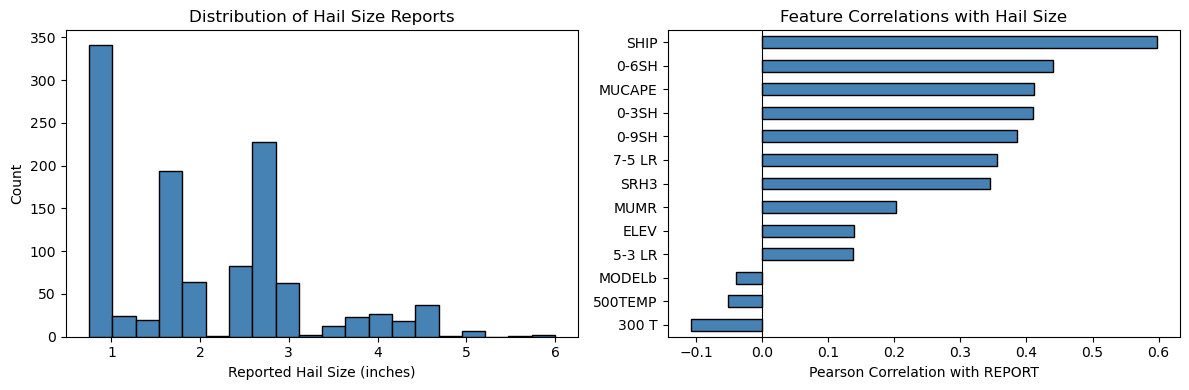

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of the target variable
axes[0].hist(data['REPORT'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Reported Hail Size (inches)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Hail Size Reports')

# Correlation of numeric features with target variable
numeric_data = data.drop(columns=['DATE / RAOB'])
correlations = numeric_data.corr()['REPORT'].drop('REPORT').sort_values()
correlations.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Pearson Correlation with REPORT')
axes[1].set_title('Feature Correlations with Hail Size')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## Step 3: Prepare Features and Target Variable

Machine learning models require two components:

- **Features (X)**: The input variables used to make predictions (atmospheric measurements)
- **Target (y)**: The continuous outcome we want to predict (hail size in inches)

In this step, we:
1. Remove non-feature columns (`DATE / RAOB`)
2. Separate the target variable (`REPORT`) from the feature matrix
3. Check for and drop any rows with missing values

Unlike classification, we do **not** need to binarize the target—we use the raw hail size values directly as our regression target.

In [4]:
x_values = data.drop(columns=['DATE / RAOB', 'REPORT'])  # Our Predictors (X)
y_values = data['REPORT']                                 # Our target: hail size in inches

# Drop rows with any missing values
mask = x_values.notna().all(axis=1) & y_values.notna()
x_values = x_values[mask].reset_index(drop=True)
y_values = y_values[mask].reset_index(drop=True)

print(f"Dataset shape: {x_values.shape[0]} samples, {x_values.shape[1]} features")
print(f"Target range: {y_values.min():.2f} – {y_values.max():.2f} inches")
x_values

Dataset shape: 1148 samples, 13 features
Target range: 0.75 – 6.00 inches


,ELEV,MUCAPE,MUMR,500TEMP,300 T,7-5 LR,5-3 LR,0-3SH,0-6SH,0-9SH,SRH3,SHIP,MODELb
0,791,4181,15.3,-9.6,-36.2,7.5,7.1,23.4,19.4,26.8,325,1.9,3.0
1,873,4692,14.9,-10.8,-37.3,8.8,7.2,14.2,13.2,18.1,-37,1.9,2.7
2,357,5751,18.8,-9.5,-36.1,7.4,7.1,14.5,23.6,45.9,116,3.1,3.5
3,165,2240,12.3,-17.3,-41.7,7.6,6.8,23.0,26.3,32.1,294,2.3,3.0
4,791,2820,13.7,-8.3,-34.7,7.6,7.1,12.9,20.3,15.8,142,1.2,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,13,3152,17.4,-7.3,-32.7,6.2,6.8,1.8,2.6,4.4,8,0.3,0.6
1144,1288,931,8.3,-10.3,-36.9,8.5,7.2,13.6,16.1,22.9,203,0.3,1.4
1145,317,520,9.6,-16.3,-41.3,5.8,6.9,3.9,17.5,30.9,50,0.2,0.7
1146,101,3507,17.3,-6.1,-32.3,6.0,7.0,7.1,2.3,8.6,-1,0.3,0.7


## Step 4: Train-Test Split

One of the most important principles in machine learning is **never to train and test on the same data**. This would be like studying with the exact exam questions—you wouldn't know if you truly learned the material or just memorized the answers.

We split our data into:
- **Training Set (80%)**: Used to fit the model and learn patterns
- **Testing Set (20%)**: Held completely separate, used only at the end to evaluate final performance

**Critical Rule**: Don't look at the test set during model development! Any decision influenced by test performance creates **data leakage**—you're cheating by letting test information influence training choices.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(x_values, y_values, test_size=0.20, random_state=42)
print(f"Training samples: {len(X_train)}   |   Test samples: {len(X_test)}")

Training samples: 918   |   Test samples: 230


## Step 5: Build ML Pipelines

A **pipeline** combines preprocessing and modeling steps into a single object. This ensures consistent transformations and prevents data leakage.

### Our Pipelines

1. **StandardScaler**: Transforms features to mean=0, std=1. Algorithms like SVR are sensitive to feature scale—this ensures all variables are on a comparable footing.

2. **Models**:
   - **Decision Tree Regressor**: Recursively splits the feature space into regions and predicts the mean target value in each region. Interpretable and handles non-linear relationships.
   - **SVR (Support Vector Regressor)**: Fits a hyperplane that has at most `ε` deviation from the actual targets. Effective on moderate-sized datasets with complex patterns.

### Hyperparameters

- **Tree `max_depth=4`**: Limits tree depth to 4 levels, reducing overfitting
- **SVR `C=7.5`**: Controls trade-off between fitting training data and maintaining a smooth fit

We will manually set these first, then use Grid Search to find optimal values systematically.

In [6]:
model_svr = Pipeline(steps=[('scaling', StandardScaler()),
                             ('svr', SVR(C=7.5))])

model_tree = Pipeline(steps=[('scaling', StandardScaler()),
                              ('tree', DecisionTreeRegressor(max_depth=4))])

## Step 6: Train the Models

Training happens with the `.fit()` method, which:

1. **Fits the scaler** on training data (learns mean and std from training features only)
2. **Applies scaling** to the training data using learned parameters
3. **Fits the model** on the scaled training data, learning how features relate to hail size

This is where the "learning" happens—the model adjusts its internal parameters to minimize prediction error on the training set.

**Key Point**: We only use `X_train` and `y_train` here. The models have no knowledge of the test set.

In [7]:
# Run the .fit() function to start the training of the ML Pipeline.
model_svr.fit(X_train, y_train)
model_tree.fit(X_train, y_train)

Pipeline(steps=[('scaling', StandardScaler()),
                ('tree', DecisionTreeRegressor(max_depth=4))])

## Step 7: Interpret the Decision Tree

One advantage of decision trees is **interpretability**—we can see exactly what rules the model learned. In a regression tree:
- Each **internal node** applies a threshold on one feature (e.g., `SHIP <= 1.5`)
- Each **leaf node** predicts the **mean hail size** for all training samples that reach it
- The tree structure reveals which features split the data most informatively

Below we visualize the tree in both text and graphical form.

In [8]:
feature_names = list(X_train.columns)
text_tree = export_text(model_tree['tree'], feature_names=feature_names)
print(text_tree)

|--- SHIP <= -0.41
|   |--- SHIP <= -0.82
|   |   |--- ELEV <= 0.71
|   |   |   |--- MUCAPE <= -1.87
|   |   |   |   |--- value: [0.86]
|   |   |   |--- MUCAPE >  -1.87
|   |   |   |   |--- value: [1.12]
|   |   |--- ELEV >  0.71
|   |   |   |--- 300 T <= 0.69
|   |   |   |   |--- value: [1.11]
|   |   |   |--- 300 T >  0.69
|   |   |   |   |--- value: [1.44]
|   |--- SHIP >  -0.82
|   |   |--- MODELb <= 0.18
|   |   |   |--- 500TEMP <= 0.43
|   |   |   |   |--- value: [1.31]
|   |   |   |--- 500TEMP >  0.43
|   |   |   |   |--- value: [1.63]
|   |   |--- MODELb >  0.18
|   |   |   |--- 300 T <= 1.08
|   |   |   |   |--- value: [1.99]
|   |   |   |--- 300 T >  1.08
|   |   |   |   |--- value: [1.09]
|--- SHIP >  -0.41
|   |--- SHIP <= 0.11
|   |   |--- MODELb <= 0.19
|   |   |   |--- 500TEMP <= 1.57
|   |   |   |   |--- value: [1.93]
|   |   |   |--- 500TEMP >  1.57
|   |   |   |   |--- value: [5.00]
|   |   |--- MODELb >  0.19
|   |   |   |--- 500TEMP <= -0.07
|   |   |   |   |--- val

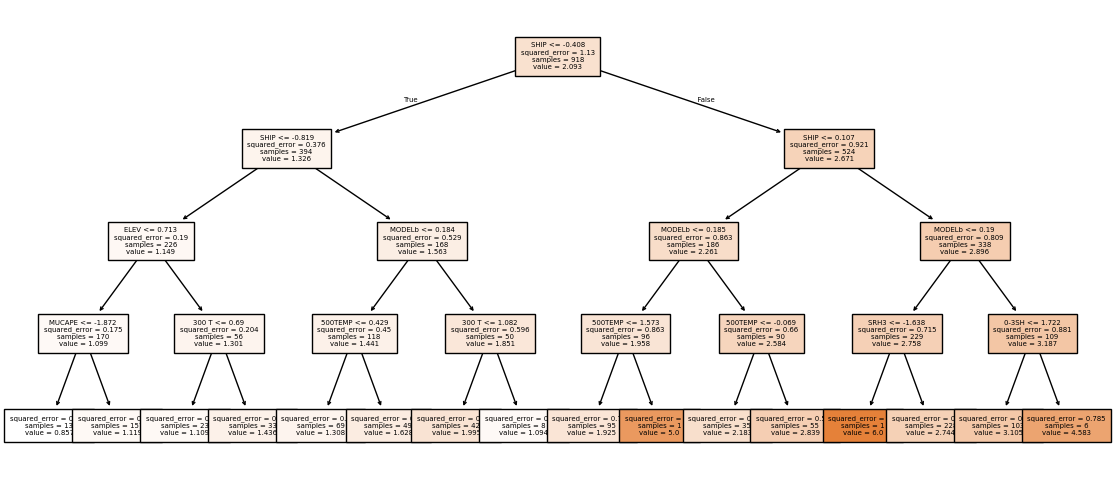

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(model_tree['tree'], feature_names=X_train.columns,
          ax=ax, fontsize=5, filled=True)
plt.savefig('regression_tree.png', dpi=300, bbox_inches='tight')
plt.show()

Now that our models are trained, we can generate predictions on the held-out test set.

In [10]:
y_predict_svr  = model_svr.predict(X_test)
y_predict_tree = model_tree.predict(X_test)

## Step 8: Evaluate Models with Regression Metrics

Unlike classification problems, regression models cannot be evaluated with a confusion matrix. Instead, we use **continuous error metrics** and visualizations:

### Regression Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Average error in the same units as hail size (inches). Easy to interpret. |
| **RMSE** (Root Mean Squared Error) | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Like MAE, but penalizes large errors more heavily. Units are inches. |
| **R²** (Coefficient of Determination) | $1 - \frac{SS_{res}}{SS_{tot}}$ | Fraction of variance explained. 1.0 = perfect, 0.0 = as good as predicting the mean. |

### Visualization: Predicted vs. Actual Plot

This is the regression equivalent of the confusion matrix. Points falling along the 1:1 diagonal indicate perfect predictions. Scatter around the line shows prediction error.

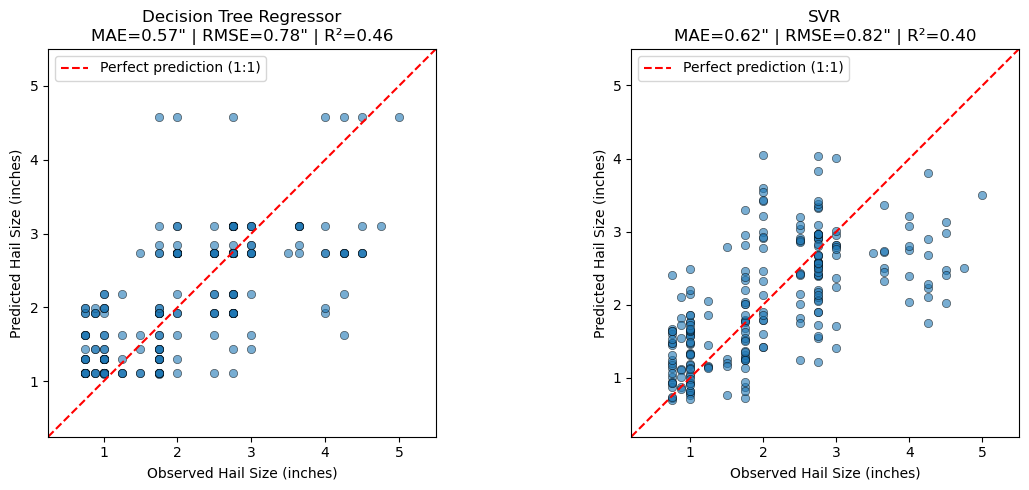

In [11]:
def plot_regression_results(y_true, y_pred, model_name, ax):
    """Plot predicted vs. actual scatter and print regression metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5)
    lims = [min(y_true.min(), y_pred.min()) - 0.5,
            max(y_true.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'r--', label='Perfect prediction (1:1)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Observed Hail Size (inches)')
    ax.set_ylabel('Predicted Hail Size (inches)')
    ax.set_title(f'{model_name}\nMAE={mae:.2f}" | RMSE={rmse:.2f}" | R²={r2:.2f}')
    ax.legend()
    ax.set_aspect('equal')
    return mae, rmse, r2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_regression_results(y_test, y_predict_tree, 'Decision Tree Regressor', axes[0])
plot_regression_results(y_test, y_predict_svr,  'SVR',                     axes[1])
plt.tight_layout()
plt.show()

---

# Part 2: Advanced Model Development—Grid Search and Cross-Validation

## The Problem with Manual Hyperparameter Selection

In Part 1, we manually chose hyperparameters (tree depth, SVR C-value) based on intuition. This approach has serious problems:

### Problem 1: Data Leakage
If we evaluate hyperparameters using the test set, we're letting test information influence our choices. Even unconsciously, we'll pick parameters that perform well on that specific test set—meaning we're fitting to it rather than learning general patterns.

### Problem 2: Trial and Error
Manually trying values is inefficient and incomplete. We might miss the optimal configuration entirely.

## The Solution: Grid Search with Cross-Validation

**Grid Search** systematically tests all combinations of hyperparameter values. For each combination, **Cross-Validation** robustly estimates performance without touching the test set.

### How It Works

1. **Define a parameter grid**: All combinations to test (e.g., max_depth ∈ {2, 4, 7, 12, 16} and n_components ∈ {1…11})
2. **k-Fold Cross-Validation**: Divide training data into k folds
3. For each combination: train k models (leaving one fold out each time), score on the held-out fold, average the k scores
4. **Select the best**: Use the combination with the best average score
5. **Final evaluation**: Test on the held-out test set we haven't touched until now

### Scoring for Regression

Instead of accuracy, we use `neg_mean_squared_error`: the negative mean squared error (GridSearchCV maximizes, so we negate MSE to turn minimization into maximization).

In [12]:
# Define the pipeline: StandardScaler -> PCA -> Decision Tree Regressor
model_tree = Pipeline([('scaling', StandardScaler()),
                       ('pca', PCA()),
                       ('tree', DecisionTreeRegressor())])

## Step 9: Define the Hyperparameter Search Space

In grid search, we specify all hyperparameter values to test. This creates a "grid" of combinations to explore.

### Hyperparameter 1: Tree Depth

- **Shallow trees** (depth=2): Few splits, simple rules, may underfit  
- **Deep trees** (depth=16): Many splits, complex rules, may overfit  
- **Optimal depth**: Some middle value that balances these tradeoffs

### Hyperparameter 2: PCA Components

**Principal Component Analysis (PCA)** reduces the number of features by projecting data onto directions of maximum variance. For regression, fewer components keep the model simpler (less overfitting); too few may lose important predictive signal.

Our grid tests 5 depths × 11 component counts = **55 combinations**. GridSearchCV will evaluate all of them using cross-validation.

In [13]:
parameter_grid = [{'tree__max_depth': [2, 4, 7, 12, 16],
                   'pca__n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}]

## Step 10: Cross-Validation—Robust Performance Estimation

Cross-validation estimates model performance without using the test set by resampling the training data.

### k-Fold Cross-Validation (k=5)

1. **Divide** training data into 5 equal parts
2. For each fold, train on the other 4 parts and validate on the 1 held-out part
3. **Average** the 5 validation scores

### Why Cross-Validation?

- **Robust estimate**: A single hold-out split can be unrepresentative
- **Better use of data**: All training samples are used for both training and validation at different points
- **Overfitting detection**: If training scores are much lower (better) than cross-validation scores, the model is overfitting

### Scoring for Regression

We use `scoring='neg_mean_squared_error'`. Because GridSearchCV **maximizes** the score, negating MSE turns the minimization problem into a maximization one. A score of –0.5 is better than –1.5.

In [14]:
k = 5
regressor = GridSearchCV(estimator=model_tree, param_grid=parameter_grid,
                         cv=k, scoring='neg_mean_squared_error')

## Step 11: Execute Grid Search

Calling `.fit()` on GridSearchCV triggers the complete search:

- 55 hyperparameter combinations (5 depths × 11 PCA components)
- Each evaluated with 5-fold cross-validation
- **275 total model fits** — all automated!

The result tells us which combination minimizes average MSE across folds.

In [15]:
regressor.fit(X_train, y_train)

/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.compone

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaling', StandardScaler()),
                                       ('pca', PCA()),
                                       ('tree', DecisionTreeRegressor())]),
             param_grid=[{'pca__n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                                11],
                          'tree__max_depth': [2, 4, 7, 12, 16]}],
             scoring='neg_mean_squared_error')

## Step 12: Examine Best Hyperparameters

GridSearchCV stores the winning configuration in `best_params_` and the best fitted pipeline in `best_estimator_`. Examine these to understand which tree depth and number of PCA components minimized cross-validation MSE on the hail dataset.

In [16]:
print("Best parameters found:")
print(regressor.best_params_)
print()
print("Best estimator:")
print(regressor.best_estimator_)

Best parameters found:
{'pca__n_components': 2, 'tree__max_depth': 4}

Best estimator:
Pipeline(steps=[('scaling', StandardScaler()), ('pca', PCA(n_components=2)),
                ('tree', DecisionTreeRegressor(max_depth=4))])


## Step 13: Final Evaluation on Test Set

Now comes the crucial moment: evaluating our optimized model on the test set, which we have never used during training or hyperparameter tuning. This gives an honest estimate of how the model will perform on truly new storm observations.

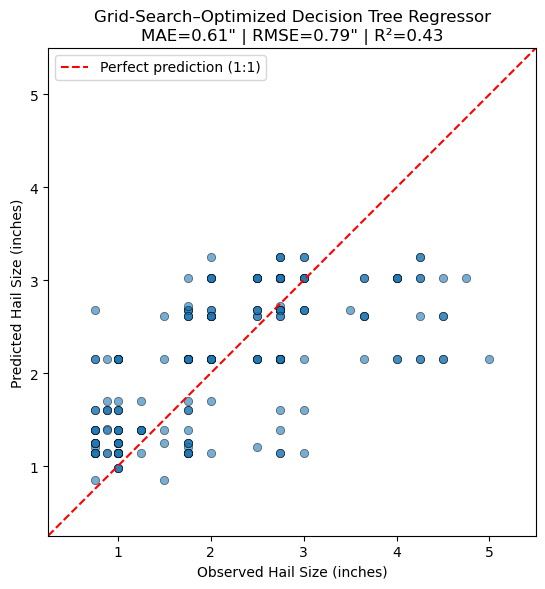

In [17]:
y_predict = regressor.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
plot_regression_results(y_test, y_predict, 'Grid-Search–Optimized Decision Tree Regressor', ax)
plt.tight_layout()
plt.show()

We can also visualize how the cross-validation score varied across the hyperparameter grid. This reveals the bias-variance tradeoff in action: very simple models (shallow trees, few PCA components) underfit; very complex models overfit.

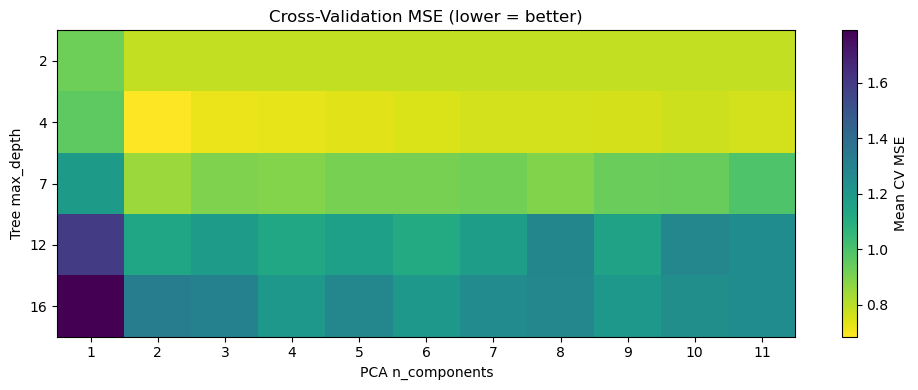

In [18]:
results = pd.DataFrame(regressor.cv_results_)

# Pivot to make a heatmap: rows = max_depth, cols = n_components
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_tree__max_depth',
    columns='param_pca__n_components'
)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(-pivot.values, aspect='auto', cmap='viridis_r')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_xlabel('PCA n_components')
ax.set_ylabel('Tree max_depth')
ax.set_title('Cross-Validation MSE (lower = better)')
plt.colorbar(im, ax=ax, label='Mean CV MSE')
plt.tight_layout()
plt.show()

---

# Part 3: Ensemble Methods—Random Forest Regressor

## The Power of Ensembles

In Parts 1 and 2, we built single models. A better approach is building **ensemble models**—many weak learners combined to create a stronger predictor.

### Random Forest for Regression

**Random Forest** is an ensemble of decision trees built using randomization:

1. **Bootstrap sampling**: Create many training sets by sampling with replacement from the original data
2. **Train trees**: Fit a full decision tree to each bootstrap sample
3. **Random feature selection**: At each split, consider only a random subset of features (this decorrelates the trees)
4. **Combine predictions**: For regression, **average** the predictions of all trees (rather than taking a majority vote as in classification)

### Why Random Forest Works

- **Reduces overfitting**: Individual deep trees overfit; averaging smooths this out
- **Handles non-linearity**: Captures complex interaction effects between predictors
- **Feature importance**: Tells us which atmospheric variables are most predictive of hail size
- **Robust**: Less sensitive to outliers than single trees

### Grid Search for Random Forest

We now apply grid search with cross-validation to optimize:
- `n_estimators`: Number of trees (more trees → more stable predictions, slower to train)
- `max_depth`: Maximum depth of each tree
- `pca__n_components`: Number of PCA components to retain

In [19]:
from sklearn.ensemble import RandomForestRegressor

model_rf = Pipeline([('scaling', StandardScaler()),
                     ('pca', PCA()),
                     ('rf', RandomForestRegressor(random_state=42))])

parameter_grid_rf = [{'rf__max_depth':    [2, 4, 7],
                      'rf__n_estimators': [100],
                      'pca__n_components': [4, 5, 6, 7, 8, 9, 10, 11]}]

k = 10
regressor_rf = GridSearchCV(estimator=model_rf, param_grid=parameter_grid_rf,
                             cv=k, scoring='neg_mean_squared_error')

regressor_rf.fit(X_train, y_train)
print("Best RF parameters:")
print(regressor_rf.best_params_)

/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.compone

Best RF parameters:
{'pca__n_components': 4, 'rf__max_depth': 7, 'rf__n_estimators': 100}


/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.compone

Let's evaluate the Random Forest on the held-out test set and compare it to the single decision tree from Part 2.

/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


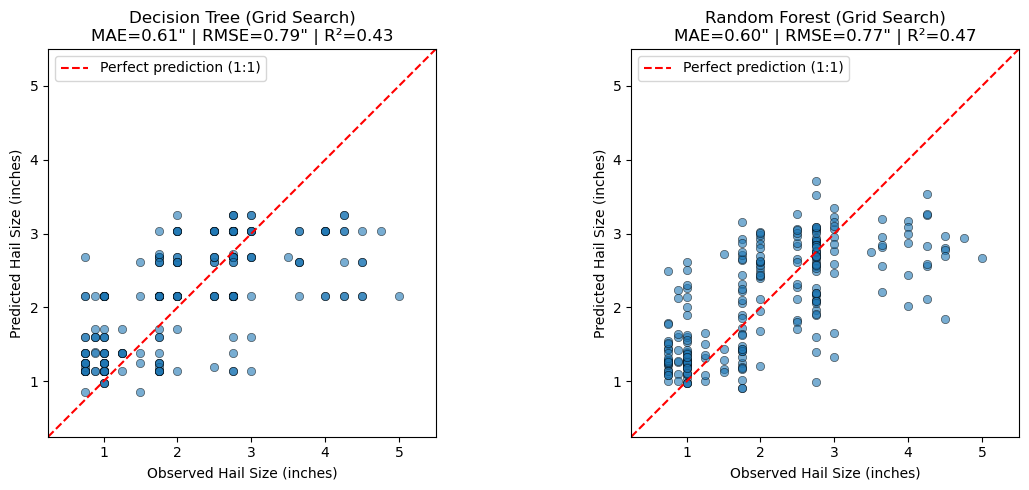

In [20]:
y_predict_rf   = regressor_rf.predict(X_test)
y_predict_tree = regressor.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_regression_results(y_test, y_predict_tree, 'Decision Tree (Grid Search)', axes[0])
plot_regression_results(y_test, y_predict_rf,   'Random Forest (Grid Search)', axes[1])
plt.tight_layout()
plt.show()

### Feature Importance

Random Forest calculates **feature importance** scores by measuring how much each feature reduces prediction error (MSE) when it is used in a split, averaged across all trees. This tells us which atmospheric variables most strongly predict hail size.

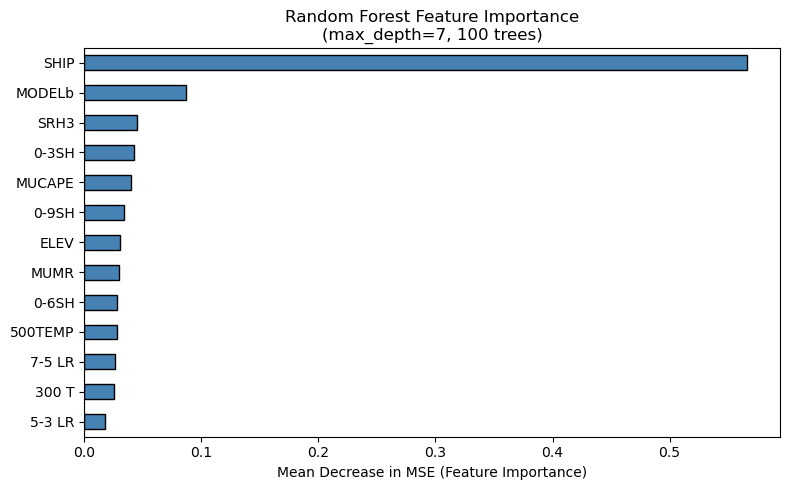

In [21]:
# Feature importance is defined in the original (pre-PCA) feature space only when PCA is not used.
# Here we retrain a Random Forest without PCA on the best depth to get interpretable importances.
best_depth = regressor_rf.best_params_['rf__max_depth']

model_rf_no_pca = Pipeline([('scaling', StandardScaler()),
                              ('rf', RandomForestRegressor(n_estimators=100,
                                                           max_depth=best_depth,
                                                           random_state=42))])
model_rf_no_pca.fit(X_train, y_train)

importances = model_rf_no_pca['rf'].feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Mean Decrease in MSE (Feature Importance)')
ax.set_title(f'Random Forest Feature Importance\n(max_depth={best_depth}, 100 trees)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---

## Summary: Key Takeaways on Building Regression Models

### The Machine Learning Regression Workflow

The complete process we followed:

1. **Load & Explore**: Understand your data and the distribution of the target variable
2. **Prepare**: Separate features (X) and target (y); handle missing values
3. **Split**: Separate training and test sets (80/20)
4. **Preprocess**: Scale features with StandardScaler; optionally reduce dimensions with PCA
5. **Select Model(s)**: Choose appropriate regression algorithms
6. **Optimize Hyperparameters**: Use grid search + cross-validation (score: `neg_mean_squared_error`)
7. **Evaluate**: Report MAE, RMSE, and R² on held-out test data; inspect predicted vs. actual plot
8. **Interpret**: Examine decision tree structure or Random Forest feature importances

### Critical Principles

**Data Leakage Prevention**: Never let information from the test set influence model development:
- Always fit preprocessing (scaling, PCA) only on training data
- Use cross-validation on training data for hyperparameter selection
- Evaluate on the test set only once, at the very end

**Regression Evaluation Metrics**:
- **MAE**: Intuitive—average error in the original units (inches). Not sensitive to outliers.
- **RMSE**: Penalizes large errors more heavily. Useful when big misses are particularly costly.
- **R²**: Fraction of variance explained. Comparable across datasets with different scales.

### When to Use Each Algorithm

- **Decision Tree Regressor**: When interpretability is crucial; good for showing rule-based predictions
- **SVR**: Good on moderate-sized, high-dimensional datasets; handles non-linear patterns with kernels
- **Random Forest**: When accuracy is the priority; robust to overfitting; provides feature importance

### Common Pitfalls to Avoid

1. **Using test data during development**: Leads to overoptimistic error estimates
2. **Not checking the target distribution**: Heavily skewed targets may benefit from log-transformation
3. **Ignoring feature importance**: Understanding which variables drive predictions aids physical interpretation
4. **Choosing metrics poorly**: Choose MAE vs. RMSE based on whether large errors are disproportionately costly
5. **Over-complex models**: A deep unconstrained tree will memorize training data and generalize poorly